# Potential and Limitation of QELMs

In this notebook I want to reprodue the results of https://arxiv.org/abs/2210.00780.

First of all I want to generate a training dataset, a set of denisty matrices with the corresponding expectation value of chosen observable.

In [29]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

#let's define the Pauli matrices
I = np.array([[1, 0],
              [0, 1]], dtype=complex)

X = np.array([[0, 1],
              [1, 0]], dtype=complex)

Y = np.array([[0, -1j],
              [1j,  0]], dtype=complex)

Z = np.array([[1,  0],
              [0, -1]], dtype=complex)

In [30]:
N_tr = 100
N_test = 1000

#density matrices
rho_training = np.zeros((N_tr, 2, 2), dtype=complex)
rho_test = np.zeros((N_test,2,2), dtype=complex)

#expectation values
expe_X_train = np.zeros(N_tr)
expe_X_test = np.zeros(N_test)

expe_Y_train = np.zeros(N_tr)
expe_Y_test = np.zeros(N_test)

expe_Z_train = np.zeros(N_tr)
expe_Z_test = np.zeros(N_test)

In [31]:
for i in range(N_tr):
    #sample a random Bloch vector uniformly in the Bloch ball
    r = np.random.normal(size=3)
    r = r / np.linalg.norm(r) * np.random.rand()**(1/3)
    
    #construct density matrix
    rho_training[i] = 0.5 * (I + r[0]*X + r[1]*Y + r[2]*Z)

    #expectation value of Pauli X
    expe_X_train[i] = np.real(np.trace(rho_training[i] @ X))
    expe_Y_train[i] = np.real(np.trace(rho_training[i] @ Y))
    expe_Z_train[i] = np.real(np.trace(rho_training[i] @ Z))

for i in range(N_test):
    #sample a random Bloch vector uniformly in the Bloch ball
    r = np.random.normal(size=3)
    r = r / np.linalg.norm(r) * np.random.rand()**(1/3)
    
    #construct density matrix
    rho_test[i] = 0.5 * (I + r[0]*X + r[1]*Y + r[2]*Z)

    #cxpectation value of Pauli X
    expe_X_test[i] = np.real(np.trace(rho_test[i] @ X))
    expe_Y_test[i] = np.real(np.trace(rho_test[i] @ Y))
    expe_Z_test[i] = np.real(np.trace(rho_test[i] @ Z))


Another way to generate random density matrices

In [32]:
def generate_random_density_matrix(dim):
    # 1. Create a random complex matrix G
    G = (np.random.randn(dim, dim) + 1j * np.random.randn(dim, dim))
    
    # 2. Compute G * G_dagger (makes it Hermitian and Positive)
    A = G @ G.conj().T
    
    # 3. Normalize the trace to 1
    rho = A / np.trace(A)
    return rho

Visualize the states inside the Bloch sphere

In [33]:
def density_to_bloch(rho):
    x = np.real(np.trace(rho @ X))
    y = np.real(np.trace(rho @ Y))
    z = np.real(np.trace(rho @ Z))
    return np.array([x, y, z])

def plot_bloch_sphere(points):
    fig = plt.figure(figsize=(7,7))
    ax = fig.add_subplot(111, projection='3d')

    # Draw sphere surface
    u = np.linspace(0, 2*np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones(np.size(u)), np.cos(v))
    
    ax.plot_surface(x, y, z, color='lightblue', alpha=0.1)

    # Draw axes
    ax.quiver(0,0,0, 1,0,0, color='r')
    ax.quiver(0,0,0, 0,1,0, color='g')
    ax.quiver(0,0,0, 0,0,1, color='b')

    # Plot points
    points = np.array(points)
    ax.scatter(points[:,0], points[:,1], points[:,2], 
               color='black', s=40)

    ax.set_xlim([-1,1])
    ax.set_ylim([-1,1])
    ax.set_zlim([-1,1])
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    ax.set_box_aspect([1,1,1])
    plt.show()

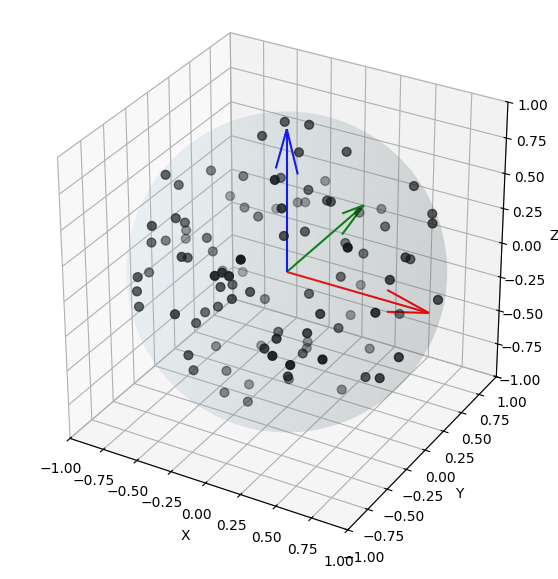

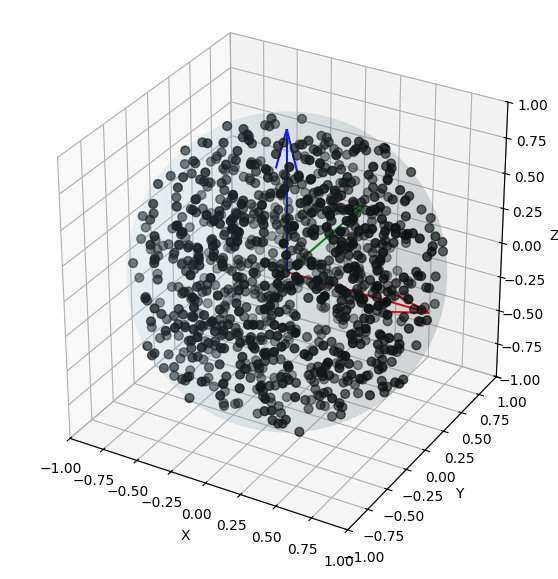

In [34]:
bloch_points_1 = [density_to_bloch(rho) for rho in rho_training]
plot_bloch_sphere(bloch_points_1)

bloch_points_2 = [density_to_bloch(rho) for rho in rho_test]
plot_bloch_sphere(bloch_points_2)

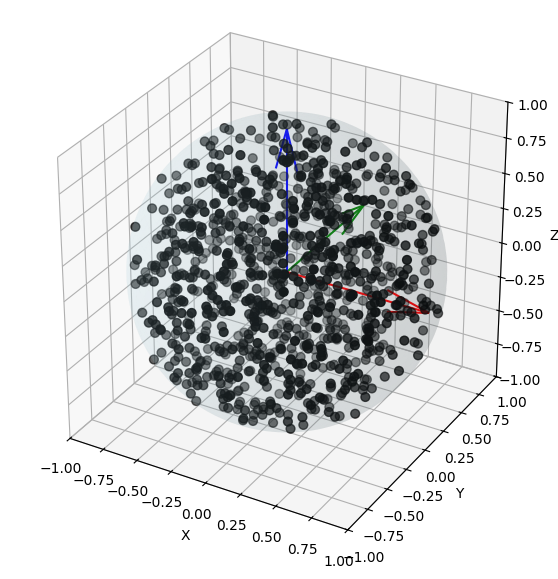

In [35]:
test = np.zeros((N_test, 2, 2), dtype=complex)

for i in range(N_test):
    test[i] = generate_random_density_matrix(2)

test_bloch = [density_to_bloch(rho) for rho in test]
plot_bloch_sphere(test_bloch)

Simulating the evoultion, let's generate the random isometry

In [36]:
def random_isometry(d_in=2, d_out=64):
    """
    A function to generate a random isometry
    """
    X = (np.random.randn(d_out, d_out) +
         1j * np.random.randn(d_out, d_out)) / np.sqrt(2)
    Q, R = np.linalg.qr(X)

    diag = np.diag(R)
    phases = diag / np.abs(diag)
    Q = Q * phases

    return Q[:, :d_in]

V = random_isometry(2, 64)
print(np.allclose(V.conj().T @ V, np.eye(2)))

True


Generate a random POVM

In [37]:
def generate_random_povm(dim, num_elements):
    """ 
    A function to generate a random povm
    """
    elements = []
    total_sum = np.zeros((dim, dim), dtype=complex)
    
    for _ in range(num_elements):
        # Generate a random complex matrix
        A = np.random.randn(dim, dim) + 1j * np.random.randn(dim, dim)
        # Make it positive semi-definite (A * A_dagger)
        M = A @ A.conj().T
        elements.append(M)
        total_sum += M
        
    # Normalize so they sum to Identity
    # Use the matrix square root of the inverse sum to normalize
    from scipy.linalg import sqrtm, inv
    normalization = inv(sqrtm(total_sum))
    
    povm = [normalization @ E @ normalization for E in elements]
    return povm

In [38]:
counts = list(range(1, 17))


povm_families = {n: generate_random_povm(32,n) for n in counts}
    
c = sum(povm_families[5])

print(c)

[[ 1.00000000e+00-7.58941521e-19j  1.04430353e-15-1.21517379e-15j
  -9.08995101e-16-3.90312782e-16j ... -2.70616862e-16+3.66894015e-16j
   5.86336535e-16-1.01568060e-15j  9.40220124e-16+4.64905892e-16j]
 [ 1.57512892e-15+1.31145095e-15j  1.00000000e+00-1.82511883e-16j
   1.75207071e-15+2.09207651e-15j ... -1.70002901e-15-3.26128013e-16j
  -3.92047506e-16-2.22044605e-16j -7.35522754e-16+8.15320034e-17j]
 [-8.96852037e-16+4.85722573e-16j  1.76594850e-15-2.34187669e-15j
   1.00000000e+00+1.27447965e-16j ...  2.91433544e-16-2.08166817e-16j
   2.34404510e-15+7.32053307e-16j -1.56125113e-16-4.75314232e-16j]
 ...
 [-3.95516953e-16-4.15032592e-16j -1.61502756e-15+3.85108612e-16j
   4.51028104e-16+2.30718222e-16j ...  1.00000000e+00+9.59518923e-17j
   7.97972799e-17-2.48065457e-16j -1.19348975e-15-5.31692745e-16j]
 [ 3.71230824e-16+1.17527515e-15j -5.01335085e-16+1.94289029e-16j
   2.02518124e-15-4.63171168e-16j ...  1.63064007e-16+3.28730099e-16j
   1.00000000e+00-2.04372110e-16j -3.17454396e-

In [39]:
    
def out_probabilites(rho, povm, shots):
    """
    Computes the estimated probabilities od povm outcomes based
    on a finite/infinte number of measurements.
    """
    # if shots = 0, we return the theoretical probabilities without sampling
    if shots == 0:

        probs = [(M @ rho).trace().real for M in povm]

        probs = np.array(probs) / np.sum(probs)

        return probs
    
    else: 
         #calculate theoretical probabilities: p_i = Tr(M_i * rho)
         #we take the real part because Tr is Hermitian but might have tiny imag noise
         probs = [(M @ rho).trace().real for M in povm]
        
         #ensure probabilities sum to 1
         probs = np.array(probs) / np.sum(probs)
        
         #sample from the multinomial distribution
         counts = np.random.multinomial(shots, probs)
        
         #observed frequencies (Finite Statistics)
         observed_probs = counts / shots
        
         return observed_probs

In [40]:
rho_te= generate_random_density_matrix(32)
povm_te = povm_families[10]

est_probs = out_probabilites(rho_te, povm_te, 0)

print(est_probs)
print(np.sum(est_probs))

[0.1008467  0.09902674 0.10420651 0.09927003 0.09757839 0.0979288
 0.10359019 0.09914007 0.10364593 0.09476664]
0.9999999999999998


In [41]:
#test to see how partial trace works
rho_a = np.array([[0.5, 0.5, 0.5],
                  [0.5, 0.5,0.5],
                  [0.5,0.5,0]])

rho_b = np.array([[0, 0],
                  [0, 1]])

# Compute the tensor product
rho_ab = np.kron(rho_a, rho_b)

print("Density Matrix rho_AB:")
print(rho_ab)

def partial_trace(rho, keep_subsystem, dims):
    """
    rho: The joint density matrix
    keep_subsystem: 0 to keep system A, 1 to keep system B
    dims: list of dimensions [dim_A, dim_B]
    """
    # Reshape into a 4D tensor: (dim_A, dim_B, dim_A, dim_B)
    reshaped_rho = rho.reshape(dims + dims)
    
    if keep_subsystem == 0:
        # Trace out B (axis 1 and 3)
        return np.trace(reshaped_rho, axis1=1, axis2=3)
    else:
        # Trace out A (axis 0 and 2)
        return np.trace(reshaped_rho, axis1=0, axis2=2)

#test

prova_1 = partial_trace(rho_ab, 0, [3,2])
print(prova_1)

prova_2 = partial_trace(rho_ab, 1, [3,2])
print(prova_2)

Density Matrix rho_AB:
[[0.  0.  0.  0.  0.  0. ]
 [0.  0.5 0.  0.5 0.  0.5]
 [0.  0.  0.  0.  0.  0. ]
 [0.  0.5 0.  0.5 0.  0.5]
 [0.  0.  0.  0.  0.  0. ]
 [0.  0.5 0.  0.5 0.  0. ]]
[[0.5 0.5 0.5]
 [0.5 0.5 0.5]
 [0.5 0.5 0. ]]
[[0. 0.]
 [0. 1.]]


In [42]:
prova_3 = V @ rho_training[5] @ V.conj().T

In [43]:

def generate_dataset_probs(rho_list, povm, shots, V):
    """
    Input: List of qutip density matrices
    Output: A 2D numpy array [num_states x num_povm_elements]
    """
    num_states = len(rho_list)
    num_elements = len(povm)
    prob_matrix = np.zeros((num_states, num_elements))
    
    for idx, rho in enumerate(rho_list):
        # Using the finite statistics logic from before

        # Evolution and measurement
        rho_evolved = partial_trace((V @ rho @ V.conj().T), 1, [2,32])
        est_probs = out_probabilites(rho_evolved, povm, shots=shots)
        prob_matrix[idx, :] = est_probs
        
    return prob_matrix.T


In [44]:
print(expe_X_train.shape)
print(expe_X_train)

print(np.reshape(expe_X_train,(-1,1)).T.shape)
print(np.reshape(expe_X_train,(-1,1)).T)

(100,)
[-0.8503689  -0.55388142 -0.13275331 -0.83512     0.49239702 -0.58190073
 -0.32179442  0.15788853  0.61580987  0.67923996 -0.38895689 -0.01763508
 -0.71971065  0.64569124 -0.72977822 -0.06855107  0.61640426  0.33253747
 -0.49651762  0.2995204  -0.01213073  0.88513467 -0.67789093  0.07842592
 -0.3889582  -0.2192389  -0.04126557 -0.269515   -0.23481779 -0.72246933
  0.06811787  0.63616255  0.19289046  0.5379848  -0.0802332   0.36745293
 -0.29519992  0.28436029 -0.77493552 -0.34128556  0.6849153  -0.81355544
 -0.55241156  0.38438275 -0.30412329 -0.04494202  0.70596843 -0.63597163
 -0.11772534 -0.23556894 -0.68415665 -0.52460039 -0.342861    0.92381436
 -0.62329352  0.0877702   0.03844671 -0.66821281  0.1212996  -0.59801902
  0.12029475 -0.7727903   0.80225335 -0.65969583  0.10693037 -0.34799552
  0.24681866  0.26385187 -0.05295829  0.77519937  0.56126557  0.39811327
 -0.18761301  0.17722367  0.16078071  0.18169178 -0.56008964 -0.03101828
  0.33179153  0.05066421 -0.31607213 -0.8744

In [49]:
train_prob = {}
k = {}

for n, povm in povm_families.items():

    train_prob[n] = {}
    k[n] = {}

    shot_list = [0, 1000, 10000, 100000, 1000000]

    for s in shot_list:
        train_prob[n][s] = generate_dataset_probs(rho_training, povm, s, V)

        singular_values = np.linalg.svd(train_prob[n][s], compute_uv=False)
        if n < 4:
            k[n][s] = singular_values[0]/singular_values[-1]
        else:
        
            k[n][s] = singular_values[0]/singular_values[3]


<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_15953/2071548404.py:11: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('Singular Value ($\sigma_i$)', fontsize=12)


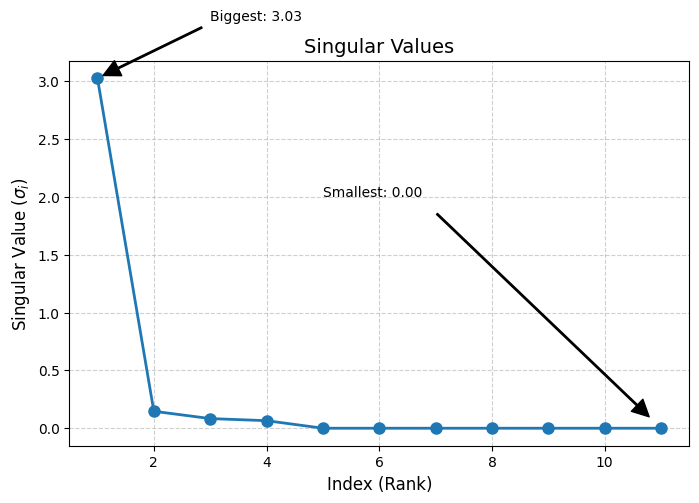

In [ ]:
# 3. Create the plot
singular_test_1 = np.linalg.svd(train_prob[11][0],compute_uv=False)

print
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(singular_test_1) + 1), singular_test_1, 'o-', markersize=8, linewidth=2)

# Labeling
plt.title('Singular Values', fontsize=14)
plt.xlabel('Index (Rank)', fontsize=12)
plt.ylabel('Singular Value ($\sigma_i$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Annotate the extremes
plt.annotate(f'Biggest: {singular_test_1[0]:.2f}', xy=(1, singular_test_1[0]), xytext=(3, singular_test_1[0]+0.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))
plt.annotate(f'Smallest: {singular_test_1[-1]:.2f}', xy=(len(singular_test_1), singular_test_1[-1]), xytext=(len(singular_test_1)-6, singular_test_1[-1]+2),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.show()


<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_15953/254975303.py:10: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('Singular Value ($\sigma_i$)', fontsize=12)


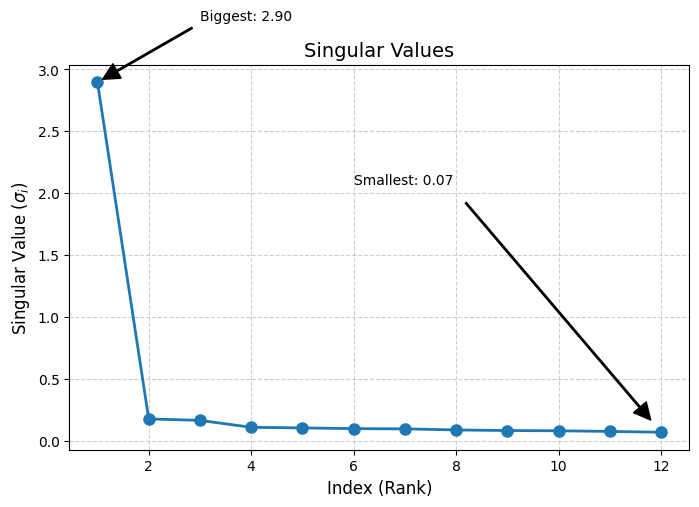

In [ ]:
# 3. Create the plot
singular_test_2 = np.linalg.svd(train_prob[12][1000] ,compute_uv=False)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(singular_test_2) + 1), singular_test_2, 'o-', markersize=8, linewidth=2)

# Labeling
plt.title('Singular Values', fontsize=14)
plt.xlabel('Index (Rank)', fontsize=12)
plt.ylabel('Singular Value ($\sigma_i$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Annotate the extremes
plt.annotate(f'Biggest: {singular_test_2[0]:.2f}', xy=(1, singular_test_2[0]), xytext=(3, singular_test_2[0]+0.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))
plt.annotate(f'Smallest: {singular_test_2[-1]:.2f}', xy=(len(singular_test_2), singular_test_2[-1]), xytext=(len(singular_test_2)-6, singular_test_2[-1]+2),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\i'
<>:11: SyntaxWarning: invalid escape sequence '\i'
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_15953/2101522153.py:11: SyntaxWarning: invalid escape sequence '\i'
  label = f"Shots: {s}" if s > 0 else "Exact ($s=\infty$)"


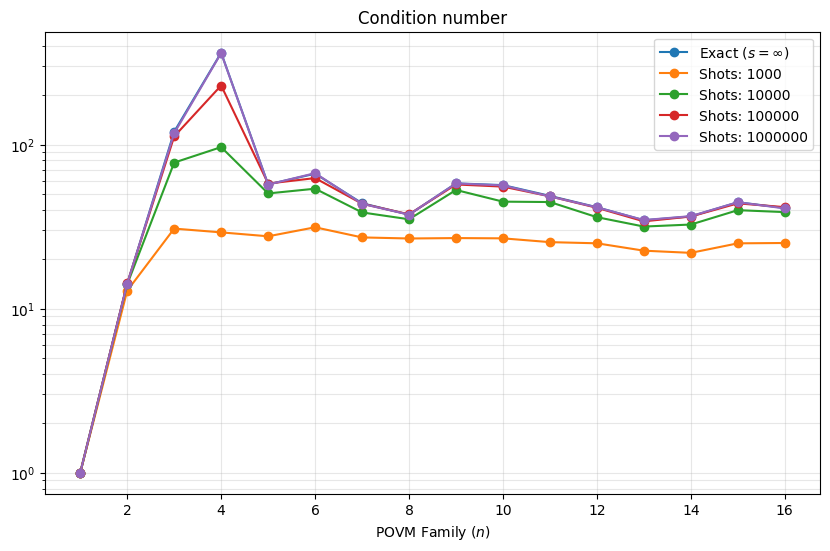

In [50]:
n_values = sorted(k.keys())
shot_values = sorted(k[n_values[0]].keys())

plt.figure(figsize=(10, 6))

# 2. Loop through shots to create one line per 's'
for s in shot_values:
    # Extract MSE for this specific 's' across all 'n'
    y_values = [k[n][s] for n in n_values]
    
    label = f"Shots: {s}" if s > 0 else "Exact ($s=\infty$)"
    plt.plot(n_values, y_values, marker='o', linestyle='-', label=label)

# 3. Formatting
plt.yscale('log') # Usually necessary for MSE to see the scale of improvement
plt.xlabel('POVM Family ($n$)')


plt.title('Condition number')
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

In [ ]:
w_trained = {}

for n, povm in povm_families.items():
    # Initialize a sub-dictionary for this specific 'n'
    w_trained[n] = {}
    
    # Define the shot counts you want to test
    shot_list = [0, 1000, 10000, 100000, 1000000]
    
    for s in shot_list:
        # Store using the shot count as the key

        # pseudo = np.linalg.pinv(generate_dataset_probs(rho_training, povm, s, V))
        w_trained[n][s] = np.reshape(expe_X_train,(-1,1)).T @ (np.linalg.pinv(train_prob[n][s]))



In [ ]:
test_prob = {}

for n, povm in povm_families.items():

    test_prob[n] = {}

    shot_list = [0, 1000, 10000, 100000, 1000000]

    for s in shot_list:
        test_prob[n][s] = generate_dataset_probs(rho_test, povm, s, V)

MSE, where training with infinite statistic

In [ ]:
MSE_Ntrain_infty = {}
for n in povm_families.keys():
    MSE_Ntrain_infty[n] = {}

    shot_list = [1000, 10000, 100000, 1000000]

    for s in shot_list:
        w = w_trained[n][0]
        X_Ntrain_infty = w @ test_prob[n][s]
        MSE_Ntrain_infty[n][s] = np.mean((X_Ntrain_infty - np.reshape(expe_X_test, (-1,1)).T)**2)

Plot

In [ ]:
n_values = sorted(MSE_Ntrain_infty.keys())
shot_values = sorted(MSE_Ntrain_infty[n_values[0]].keys())

<>:8: SyntaxWarning: invalid escape sequence '\i'
<>:16: SyntaxWarning: invalid escape sequence '\i'
<>:8: SyntaxWarning: invalid escape sequence '\i'
<>:16: SyntaxWarning: invalid escape sequence '\i'
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_15953/2993245897.py:8: SyntaxWarning: invalid escape sequence '\i'
  label = f"Shots: {s}" if s > 0 else "Exact ($s=\infty$)"
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_15953/2993245897.py:16: SyntaxWarning: invalid escape sequence '\i'
  plt.title('MSE($\infty$, Ntest)')


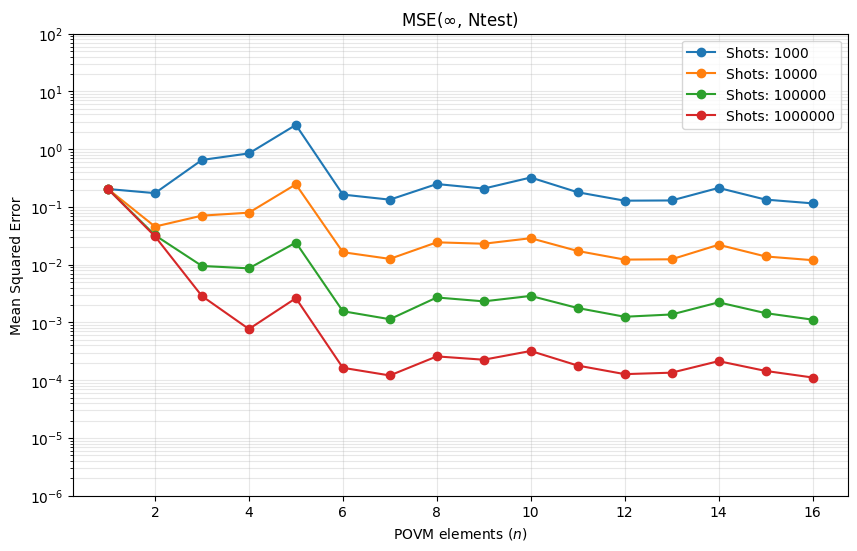

In [ ]:
plt.figure(figsize=(10, 6))

# 2. Loop through shots to create one line per 's'
for s in shot_values:
    # Extract MSE for this specific 's' across all 'n'
    y_values = [MSE_Ntrain_infty[n][s] for n in n_values]
    
    label = f"Shots: {s}" if s > 0 else "Exact ($s=\infty$)"
    plt.plot(n_values, y_values, marker='o', linestyle='-', label=label)

# 3. Formatting
plt.yscale('log') # Usually necessary for MSE to see the scale of improvement
plt.xlabel('POVM elements ($n$)')
plt.ylim(1e-6, 1e2)
plt.ylabel('Mean Squared Error')
plt.title('MSE($\infty$, Ntest)')
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()


<>:22: SyntaxWarning: invalid escape sequence '\i'
<>:30: SyntaxWarning: invalid escape sequence '\i'
<>:22: SyntaxWarning: invalid escape sequence '\i'
<>:30: SyntaxWarning: invalid escape sequence '\i'
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_15953/3393067599.py:22: SyntaxWarning: invalid escape sequence '\i'
  label = f"Shots: {s}" if s > 0 else "Exact ($s=\infty$)"
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_15953/3393067599.py:30: SyntaxWarning: invalid escape sequence '\i'
  plt.title('MSE (Ntrain, $\infty$)')


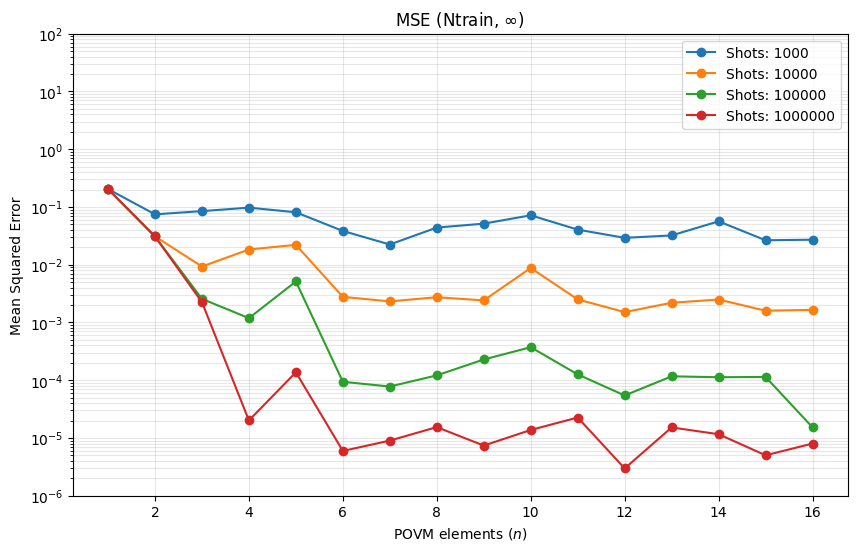

In [ ]:
MSE_Ntest_infty = {}
for n in povm_families.keys():
    MSE_Ntest_infty[n] = {}

    shot_list = [1000, 10000, 100000, 1000000]

    for s in shot_list:
        w = w_trained[n][s]
        X_Ntest_infty = w @ test_prob[n][0]
        MSE_Ntest_infty[n][s] = np.mean((X_Ntest_infty - np.reshape(expe_X_test, (-1,1)).T)**2)

n_values = sorted(MSE_Ntest_infty.keys())
shot_values = sorted(MSE_Ntest_infty[n_values[0]].keys())

plt.figure(figsize=(10, 6))

# 2. Loop through shots to create one line per 's'
for s in shot_values:
    # Extract MSE for this specific 's' across all 'n'
    y_values = [MSE_Ntest_infty[n][s] for n in n_values]
    
    label = f"Shots: {s}" if s > 0 else "Exact ($s=\infty$)"
    plt.plot(n_values, y_values, marker='o', linestyle='-', label=label)

# 3. Formatting
plt.yscale('log') # Usually necessary for MSE to see the scale of improvement
plt.xlabel('POVM elements ($n$)')
plt.ylim(1e-6, 1e2)
plt.ylabel('Mean Squared Error')
plt.title('MSE (Ntrain, $\infty$)')
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

<>:22: SyntaxWarning: invalid escape sequence '\i'
<>:22: SyntaxWarning: invalid escape sequence '\i'
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_15953/490871700.py:22: SyntaxWarning: invalid escape sequence '\i'
  label = f"Shots: {s}" if s > 0 else "Exact ($s=\infty$)"


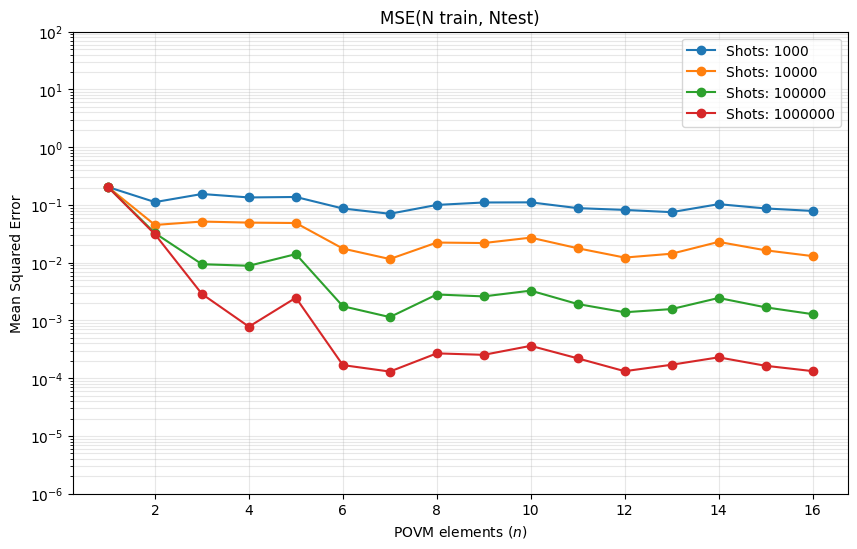

In [ ]:
MSE_finite = {}
for n in povm_families.keys():
    MSE_finite[n] = {}

    shot_list = [1000, 10000, 100000, 1000000]

    for s in shot_list:
        w = w_trained[n][s]
        X_infty = w @ test_prob[n][s]
        MSE_finite[n][s] = np.mean((X_infty - np.reshape(expe_X_test, (-1,1)).T)**2)

n_values = sorted(MSE_finite.keys())
shot_values = sorted(MSE_finite[n_values[0]].keys())


plt.figure(figsize=(10, 6))

for s in shot_values:
    
    y_values = [MSE_finite[n][s] for n in n_values]
    
    label = f"Shots: {s}" if s > 0 else "Exact ($s=\infty$)"
    plt.plot(n_values, y_values, marker='o', linestyle='-', label=label)


plt.yscale('log')
plt.xlabel('POVM elements ($n$)')
plt.ylim(1e-6, 1e2)
plt.ylabel('Mean Squared Error')
plt.title('MSE(N train, Ntest)')
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()